In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [5]:
patientData = pd.read_csv('../dataMyself/患者信息.csv')
patientData

,患者ID,性别,年龄,省,民族,宗教信仰,学历,身高,体重,BMI指数,...,烟龄,平均每日吸烟次数,是否饮酒,平均每日饮酒次数,常饮酒类,锻炼频率,刷牙频率,重症等级,所属医院,所在病区
0,1,男,55,浙江,汉族,无宗教信仰,大学及以上,171,81,27.8,...,0,0.0,饮酒,1.5,红酒,0.1,1.7,3,YH,2号楼
1,2,女,38,安徽,汉族,无宗教信仰,大学及以上,155,68,28.2,...,11,1.2,不饮酒,0.0,无,0.0,1.3,4,YH,2号楼
2,3,男,41,江苏,汉族,无宗教信仰,高中,172,64,21.7,...,18,2.0,饮酒,1.4,红酒,0.2,2.0,1,YH,2号楼
3,4,女,72,吉林,汉族,无宗教信仰,初中,161,47,18.1,...,21,1.9,不饮酒,0.0,无,0.0,1.2,3,YH,2号楼
4,5,女,68,黑龙江,汉族,无宗教信仰,高中,160,71,27.8,...,27,1.5,不饮酒,0.0,无,0.1,1.1,5,YH,2号楼
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2518,2519,女,32,浙江,汉族,无宗教信仰,高中,152,42,18.0,...,18,2.2,饮酒,1.9,啤酒,0.4,1.0,3,WT,1号楼
2519,2520,女,29,贵州,汉族,无宗教信仰,大学及以上,157,63,25.4,...,0,0.0,不饮酒,0.0,无,0.1,1.9,3,WT,1号楼
2520,2521,女,41,四川,彝族,无宗教信仰,高中,155,54,22.5,...,4,1.9,有饮酒史,1.9,红酒,0.2,1.1,3,WT,1号楼
2521,2522,男,20,安徽,汉族,无宗教信仰,高中,182,74,22.3,...,2,2.8,有饮酒史,1.9,红酒,0.6,1.4,3,WT,1号楼


In [3]:
# 统计离散型特征分布
def count(df, column):
    res = []
    values = df[column].unique().tolist()
    for val in values:
        res.append(df[df[column] == val].shape[0])

    return values, res

In [4]:
tokenCols = ['性别', '省', '民族', '宗教信仰', '学历', '体型', '过敏史', '暴露史', '是否残疾', '是否吸烟', '是否饮酒', '常饮酒类', '重症等级', '所属医院']

for col in tokenCols:
    print(count(patientData, col))

(['男', '女'], [920, 1603])
(['浙江', '安徽', '江苏', '吉林', '黑龙江', '贵州', '福建', '广东', '江西', '湖南', '山东', '海南', '陕西', '河南', '内蒙古', '青海', '甘肃', '天津', '上海', '四川', '河北', '北京', '重庆', '湖北', '广西', '辽宁', '新疆', '西藏', '云南', '山西', '宁夏'], [1030, 217, 56, 60, 57, 75, 67, 31, 123, 46, 81, 15, 78, 106, 43, 5, 6, 20, 31, 61, 56, 20, 83, 45, 21, 33, 13, 2, 8, 28, 6])
(['汉族', '土家族', '苗族', '壮族', '蒙古族', '维吾尔族', '藏族', '彝族', '回族', '满族'], [2367, 25, 38, 18, 38, 10, 3, 14, 6, 4])
(['无宗教信仰', '佛教', '伊斯兰教', '道教', '基督教', '天主教'], [2414, 18, 31, 21, 17, 22])
(['大学及以上', '高中', '初中', '小学', '文盲', '未上学'], [780, 520, 413, 371, 432, 7])
(['偏胖', '肥胖', '正常', '偏瘦'], [393, 248, 758, 1124])
(['室内灰尘过敏', '花粉过敏', '未发现', '动物毛发过敏', '无', '牛奶过敏', '鸡蛋过敏', '化妆品类过敏'], [104, 238, 1006, 153, 609, 205, 158, 50])
(['粉尘', '无', '毒物', '化学品', '射线'], [60, 2397, 26, 27, 13])
(['否', '是'], [2449, 74])
(['不吸烟', '有吸烟史', '吸烟'], [1241, 817, 465])
(['饮酒', '不饮酒', '有饮酒史'], [764, 1003, 756])
(['红酒', '无', '果酒', '白酒', '啤酒'], [440, 1003, 227, 462, 391])
([3, 4, 1, 5, 2

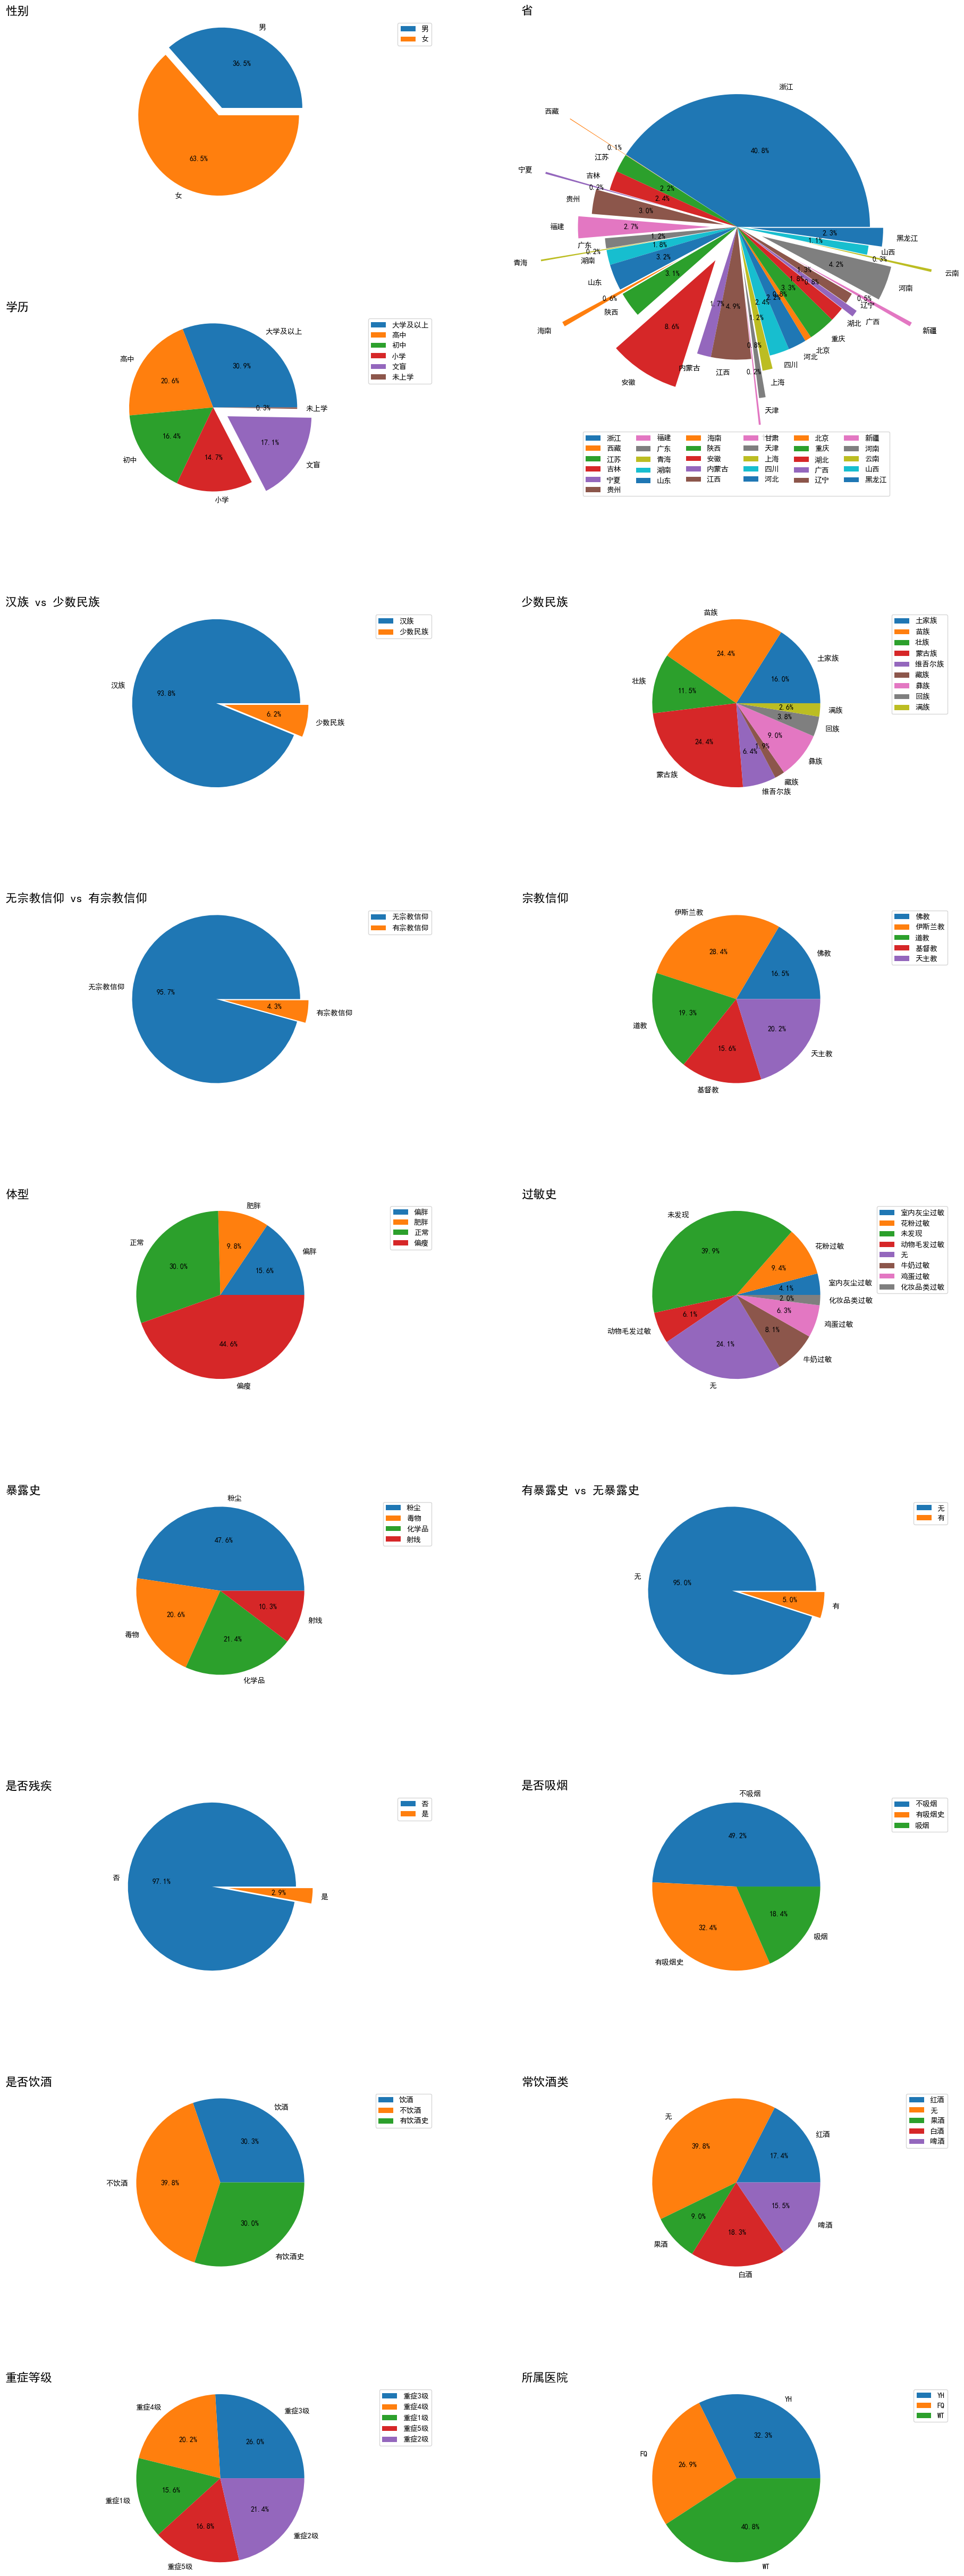

In [4]:
fig = plt.figure(figsize=(20, 60), dpi=100)
fig.subplots_adjust(left=0.01, right=0.9, bottom=0.1, top=0.9, wspace=0.2, hspace=0.6)
gs = plt.GridSpec(9, 2)

titles = ['性别', '省', '学历', '汉族 vs 少数民族', '少数民族', '无宗教信仰 vs 有宗教信仰', '宗教信仰', '体型', '过敏史', '暴露史', '有暴露史 vs 无暴露史', '是否残疾', '是否吸烟', '是否饮酒', '常饮酒类', '重症等级', '所属医院']
sizes = [
    [920, 1603],
    [1030, 2, 56, 60, 6, 75, 67, 31, 5, 46, 81, 15, 78, 217, 43, 123, 6, 20, 31, 61, 56, 20, 83, 45, 21, 33, 13, 106, 8, 28, 57],
    [780, 520, 413, 371, 432, 7],
    [2367, 156],
    [25, 38, 18, 38, 10, 3, 14, 6, 4],
    [2414, 109],
    [18, 31, 21, 17, 22],
    [393, 248, 758, 1124],
    [104, 238, 1006, 153, 609, 205, 158, 50],
    [60, 26, 27, 13],
    [2397, 126],
    [2449, 74],
    [1241, 817, 465],
    [764, 1003, 756],
    [440, 1003, 227, 462, 391],
    [655, 509, 394, 425, 540],
    [815, 679, 1029]
]
labels = [
    ['男', '女'],
    ['浙江', '西藏', '江苏', '吉林', '宁夏', '贵州', '福建', '广东', '青海', '湖南', '山东', '海南', '陕西', '安徽', '内蒙古', '江西', '甘肃', '天津', '上海', '四川', '河北', '北京', '重庆', '湖北', '广西', '辽宁', '新疆', '河南', '云南', '山西', '黑龙江'],
    ['大学及以上', '高中', '初中', '小学', '文盲', '未上学'],
    ['汉族', '少数民族'],
    ['土家族', '苗族', '壮族', '蒙古族', '维吾尔族', '藏族', '彝族', '回族', '满族'],
    ['无宗教信仰', '有宗教信仰'],
    ['佛教', '伊斯兰教', '道教', '基督教', '天主教'],
    ['偏胖', '肥胖', '正常', '偏瘦'],
    ['室内灰尘过敏', '花粉过敏', '未发现', '动物毛发过敏', '无', '牛奶过敏', '鸡蛋过敏', '化妆品类过敏'],
    ['粉尘', '毒物', '化学品', '射线'],
    ['无', '有'],
    ['否', '是'],
    ['不吸烟', '有吸烟史', '吸烟'],
    ['饮酒', '不饮酒', '有饮酒史'],
    ['红酒', '无', '果酒', '白酒', '啤酒'],
    ['重症3级', '重症4级', '重症1级', '重症5级', '重症2级'],
    ['YH', 'FQ', 'WT']
]
configs = [
    [0.1, 0],
    [0, 0.5, 0, 0, 0.5, 0.1, 0.2, 0, 0.5, 0, 0, 0.5, 0, 0.3, 0, 0, 0.5, 0.3, 0.1, 0, 0, 0, 0, 0, 0.1, 0, 0.5, 0.2, 0.5, 0, 0.1],
    [0, 0, 0, 0, 0.2, 0],
    [0, 0.1],
    [0] * 9,
    [0, 0.1],
    [0] * 5,
    [0] * 4,
    [0] * 8,
    [0] * 4,
    [0, 0.1],
    [0, 0.2],
    [0] * 3,
    [0] * 3,
    [0] * 5,
    [0] * 5,
    [0] * 3,
]

for idx in range(len(titles)):
    if idx == 0:
        axs = fig.add_subplot(gs[0, 0])
    elif idx == 1:
        axs = fig.add_subplot(gs[0:2, 1])
    elif idx == 2:
        axs = fig.add_subplot(gs[1, 0])
    else:
        if idx % 2 == 0:
            axs = fig.add_subplot(gs[idx // 2, 1])
        else:
            axs = fig.add_subplot(gs[idx // 2 + 1, 0])

    axs.pie(sizes[idx], labels=labels[idx], autopct='%1.1f%%', explode=configs[idx])
    axs.set_title(titles[idx], loc='left', fontdict={
        'fontsize': 16,
        'fontweight': 'bold',
    })
    axs.axis('equal')
    if idx == 1:
        axs.legend(loc='lower center', ncol=6)
    else:
        axs.legend(loc='best')

plt.savefig('患者离散型特征统计_plt_1.png')
plt.show()

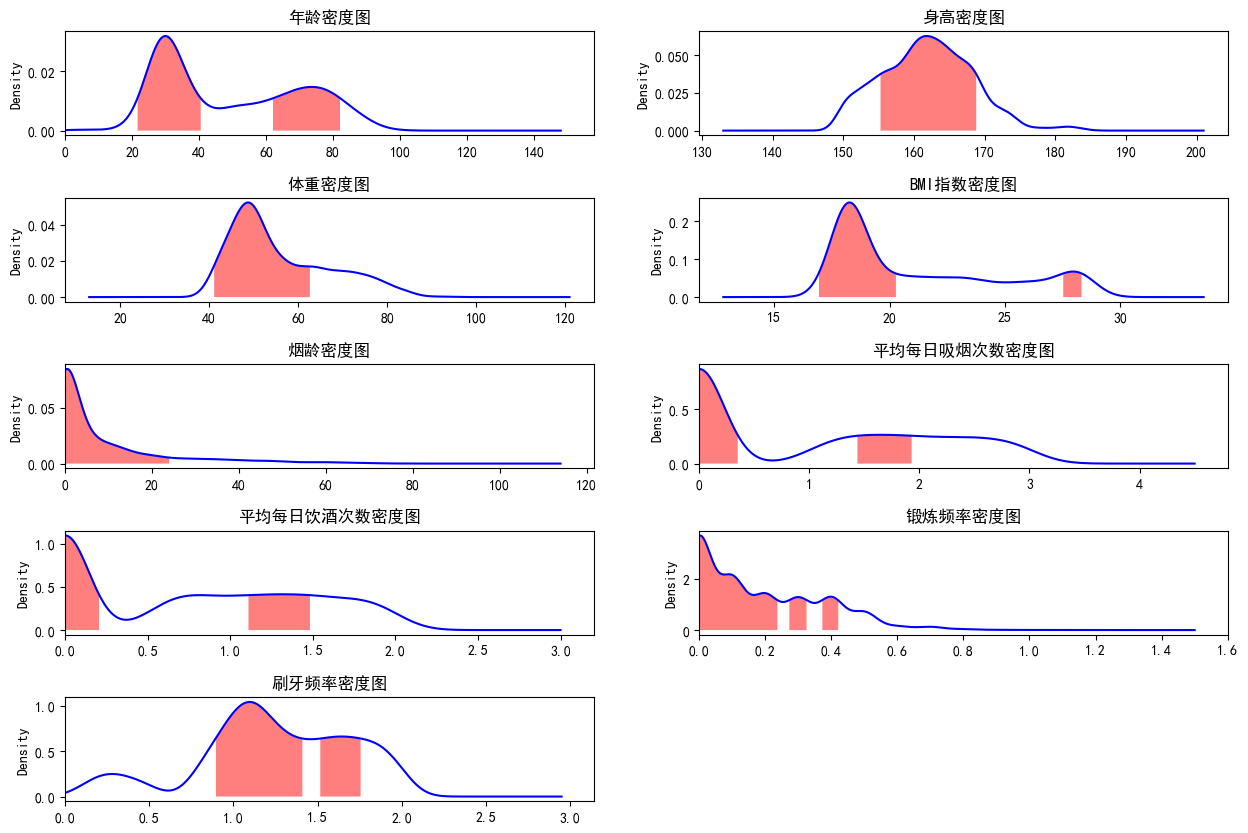

In [62]:
numberCols = ['年龄', '身高', '体重', 'BMI指数', '烟龄', '平均每日吸烟次数', '平均每日饮酒次数', '锻炼频率', '刷牙频率']

fig = plt.figure(figsize=(15, 10), dpi=100)
fig.subplots_adjust(hspace=0.6)

for idx, col in enumerate(numberCols):
    plt.subplot(5, 2, idx + 1)
    density_data = patientData[col].plot(kind='kde', label='密度图', color='blue')
    xlim = plt.xlim()
    if xlim[0] < 0:
        plt.xlim([0, xlim[1]])
    x_data = density_data.get_lines()[0].get_xdata()
    y_data = density_data.get_lines()[0].get_ydata()
    # 设定阈值，你可以根据实际情况调整
    threshold = np.percentile(y_data, 80)
    # 用于记录需要填充区间的起始和结束索引
    start_idx = None
    for i in range(len(y_data)):
        if y_data[i] >= threshold and x_data[i] >= 0:
            if start_idx is None:
                start_idx = i
        elif start_idx is not None:
            if i - start_idx > 10:
                plt.fill_between(x_data[start_idx:i], y_data[start_idx:i], facecolor='red', alpha=0.5)
            start_idx = None
    # 处理最后一个区间（如果在循环结束时还有未处理的区间）
    if start_idx is not None and len(y_data) - start_idx > 10:
        plt.fill_between(x_data[start_idx:], y_data[start_idx:], facecolor='res', alpha=0.5)

    plt.title(col + '密度图')

plt.savefig('患者连续型特征统计_plt_1.png')
plt.show()